# Project TITAN: Enterprise Retail Intelligence Platform

# Module 4: RFM Customer Segmentation

## Objective

Perform RFM (Recency, Frequency, Monetary) analysis to segment customers based on their purchasing behavior. This helps identify loyal customers, high-value customers, at-risk customers, and inactive customers for better business decisions.

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

pd.set_option("display.max_columns",None)


In [3]:
df = pd.read_csv("..//data/cleaned/cleaned_online_retail.csv")

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [5]:
df["Revenue"] = df["Quantity"] * df["Price"]

## Step 1: Calculate Recency

Recency measures how recently a customer made their last purchase.

Customers who purchased recently are generally more engaged and valuable than customers who have not purchased for a long time.

In [6]:
reference_date = df["InvoiceDate"].max()
reference_date


Timestamp('2011-12-09 12:50:00')

In [7]:
last_purchase = df.groupby("Customer ID")["InvoiceDate"].max()

last_purchase.head()

Customer ID
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
Name: InvoiceDate, dtype: datetime64[us]

In [8]:
recency = (reference_date - last_purchase).dt.days

recency.head()

Customer ID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
Name: InvoiceDate, dtype: int64

## Step 2: Calculate Frequency

Frequency measures how many orders each customer has placed.

A higher frequency indicates a more loyal and engaged customer.

In [9]:
frequency= df.groupby("Customer ID")["Invoice"].nunique()

frequency.head()

Customer ID
12346.0    12
12347.0     8
12348.0     5
12349.0     4
12350.0     1
Name: Invoice, dtype: int64

In [10]:
frequency.sort_values(ascending=False).head(10)

Customer ID
14911.0    398
12748.0    337
17841.0    211
15311.0    208
13089.0    203
14606.0    192
14156.0    156
17850.0    155
14646.0    152
18102.0    145
Name: Invoice, dtype: int64

## Step 3: Calculate Monetary

Monetary measures the total amount spent by each customer.

Customers with higher monetary values contribute more revenue to the business.

In [11]:
monetary = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
)

monetary.head()

Customer ID
12346.0    77556.46
12347.0     4921.53
12348.0     2019.40
12349.0     4428.69
12350.0      334.40
Name: Revenue, dtype: float64

In [12]:
monetary.sort_values(ascending=False).head(10)

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

## Step 4: Create RFM Table

Combine Recency, Frequency, and Monetary into a single DataFrame for customer segmentation.

In [13]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,4921.53
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


In [14]:
rfm.shape


(5881, 3)

## Step 5: RFM Scoring

Convert Recency, Frequency, and Monetary into scores from 1 to 5 using quantiles.

In [15]:
rfm["R_score"] = pd.qcut(rfm["Recency"],q=5,labels=[5,4,3,2,1])

In [16]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)

In [17]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1,2,3,4,5]
)

In [18]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_Score,M_Score
Customer ID,,,,,,
12346.0,325,12,77556.46,2,5,5
12347.0,1,8,4921.53,5,4,5
12348.0,74,5,2019.40,3,4,4
12349.0,18,4,4428.69,5,3,5
12350.0,309,1,334.40,2,1,2


## Step 6: Create RFM Score

Combine R_Score, F_Score, and M_Score into a single RFM Score.

In [19]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)


## Step 7: Customer Segmentation

Classify customers into business segments based on their RFM scores.

In [20]:
def customer_segment(row):

    if row["R_score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champion"

    elif row["R_score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customer"

    elif row["R_score"] >= 4 and row["F_Score"] <= 2:
        return "Potential Loyalist"

    elif row["R_score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    else:
        return "Lost Customer"

In [21]:
rfm["Segment"] = rfm.apply(customer_segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,325,12,77556.46,2,5,5,255,At Risk
12347.0,1,8,4921.53,5,4,5,545,Champion
12348.0,74,5,2019.40,3,4,4,344,Loyal Customer
12349.0,18,4,4428.69,5,3,5,535,Loyal Customer
12350.0,309,1,334.40,2,1,2,212,Lost Customer


In [27]:
rfm.reset_index(inplace=True)

rfm.to_csv("../data/analytics/rfm_customer_segments.csv", index=False)

print("RFM CSV Exported Successfully!")

RFM CSV Exported Successfully!


## Step 8: Customer Segment Distribution

Visualize the number of customers in each RFM segment.

In [23]:
segment_count = rfm["Segment"].value_counts()

segment_count

Segment
Lost Customer         1909
Loyal Customer        1407
Champion              1297
At Risk                824
Potential Loyalist     444
Name: count, dtype: int64

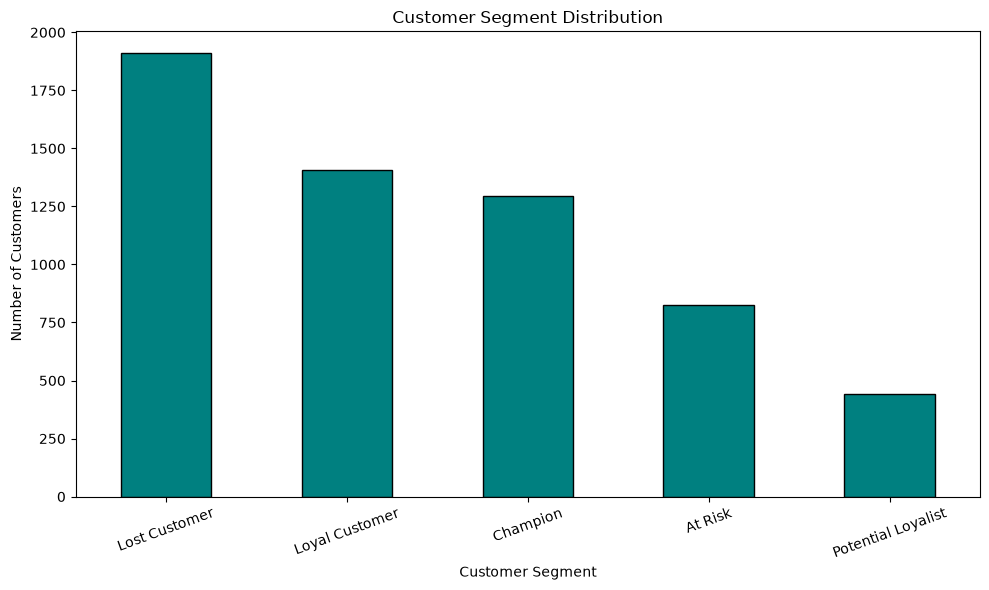

In [24]:
plt.figure(figsize=(10,6))

segment_count.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../Visuals/customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
       .sum()
       .sort_values(ascending=False)
)

pd.set_option("display.float_format", "{:.2f}".format)

segment_revenue


Segment
Champion             11859591.49
Loyal Customer        2675298.32
At Risk               1589384.31
Lost Customer          858263.12
Potential Loyalist     392267.02
Name: Monetary, dtype: float64

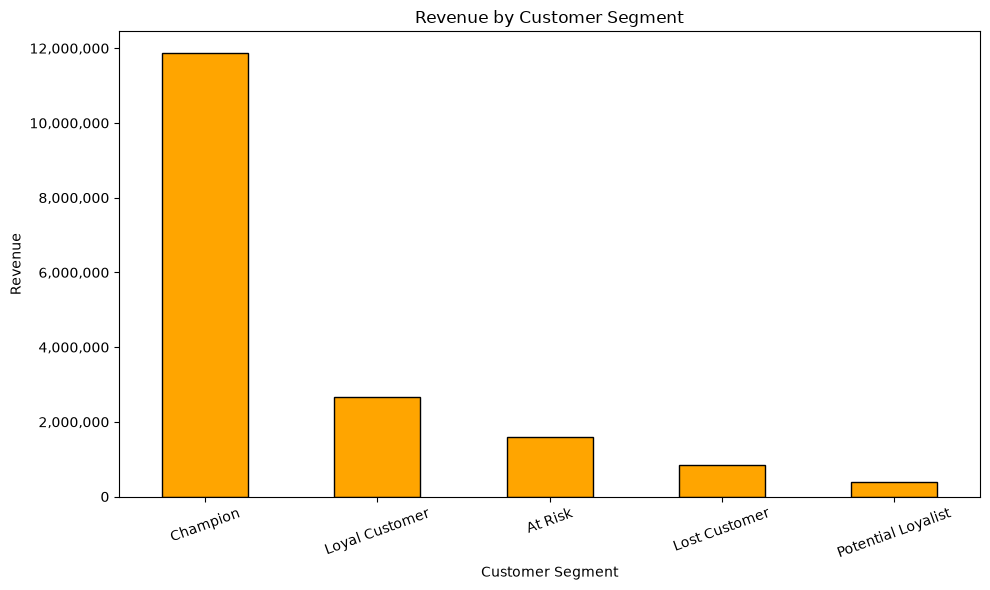

In [26]:
plt.figure(figsize=(10,6))

segment_revenue.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.xticks(rotation=20)
from matplotlib.ticker import StrMethodFormatter

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()

plt.savefig(
    "../Visuals/revenue_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()